In [1]:
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    classification_report,
    precision_recall_curve,
)

from xgboost import XGBClassifier

In [ ]:
RANDOM_STATE = 42
DATA_PATH = Path("../data/diabetes_binary_health_indicators_BRFSS2015.csv")
RESULTS_PATH = Path("../model/tuning_results.json")
MODEL_OUTPUT_PATH = Path("../model/model.pkl")
METADATA_OUTPUT_PATH = Path("../model/model_metadata.json")

In [3]:
TARGET_RECALL = None

## Load data

In [4]:
df = pd.read_csv(DATA_PATH)
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
_target_cols = ['Diabetes_binary']
_binary_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
                'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
_ordinal_cols = ['GenHlth', 'Education', 'Income', 'Age']
_gray_cols = ['MentHlth', 'PhysHlth']
_continuous_cols = ["BMI"]

In [6]:
x = df.drop(_target_cols, axis=1)
y = df[_target_cols].to_numpy().ravel()

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Full dataset: {len(df):,} rows | Train: {len(x_train):,} | Test: {len(x_test):,}")
print(f"Positive rate: {y.mean():.2%}")

Full dataset: 253,680 rows | Train: 202,944 | Test: 50,736
Positive rate: 13.93%


In [7]:
if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"""{RESULTS_PATH} not found. Run the logistic_regression, random_forest, and
        xgboost tuning notebooks first -- each one writes its own entry into this file."""
    )

with open(RESULTS_PATH) as f:
    tuning_results = json.load(f)

print(f"Found tuned results for: {list(tuning_results.keys())}")
for name, info in tuning_results.items():
    print(f"  {name}: best CV score = {info['best_score']:.5f} "
          f"(metric: {info['metric']}, saved {info['updated_at']})")

Found tuned results for: ['xgboost']
  xgboost: best CV score = 0.43908 (metric: average_precision (5-fold stratified CV), saved 2026-07-18T06:03:10.743026)


## Build each model

In [8]:
def build_logistic_regression(params: dict) -> Pipeline:
    preprocessor = ColumnTransformer([
        ("scale", StandardScaler(), _continuous_cols + _gray_cols + _ordinal_cols),
        ("passthrough", "passthrough", _binary_cols),
    ])
    model = LogisticRegression(**{"random_state": RANDOM_STATE, **params})
    
    return Pipeline([
        ("preprocess", preprocessor), ("lr", model)
    ])


def build_random_forest(params: dict) -> Pipeline:
    model = RandomForestClassifier(**{"random_state": RANDOM_STATE, "n_jobs": -1, **params})
    
    return Pipeline([
        ("rf", model)
    ])


def build_xgboost(params: dict) -> Pipeline:
    model = XGBClassifier(**{"random_state": RANDOM_STATE, "n_jobs": -1, "device": "cpu", **params})
    
    return Pipeline([
        ("xgb", model)
    ])


MODEL_BUILDERS = {
    "logistic_regression": build_logistic_regression,
    "random_forest": build_random_forest,
    "xgboost": build_xgboost,
}

## Fit on training data

In [9]:
comparison_rows = []
fitted_pipelines = {}

for model_name, builder in MODEL_BUILDERS.items():
    if model_name not in tuning_results:
        print(f"Skipping {model_name}: no entry in {RESULTS_PATH} yet.")
        continue

    params = tuning_results[model_name]["best_params"]
    pipeline = builder(params)
    pipeline.fit(x_train, y_train)

    y_prob = pipeline.predict_proba(x_test)[:, 1]
    y_pred = pipeline.predict(x_test)

    ap = average_precision_score(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    fitted_pipelines[model_name] = pipeline
    comparison_rows.append({
        "model": model_name,
        "tuning_cv_score": tuning_results[model_name]["best_score"],
        "test_average_precision": ap,
        "test_roc_auc": auc,
    })

    print(f"\n=== {model_name} ===")
    print(f"Test Average Precision: {ap:.4f} | Test ROC AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, digits=3, target_names=["No Diabetes", "Diabetes"]))

if not fitted_pipelines:
    raise RuntimeError(f"No models in {RESULTS_PATH} matched a known builder in MODEL_BUILDERS.")

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values("test_average_precision", ascending=False)
    .reset_index(drop=True)
)
comparison_df

Skipping logistic_regression: no entry in ../notebooks/model_tuning_results.json yet.
Skipping random_forest: no entry in ../notebooks/model_tuning_results.json yet.

=== xgboost ===
Test Average Precision: 0.4256 | Test ROC AUC: 0.8279
              precision    recall  f1-score   support

 No Diabetes      0.947     0.760     0.843     43667
    Diabetes      0.332     0.737     0.457      7069

    accuracy                          0.756     50736
   macro avg      0.639     0.748     0.650     50736
weighted avg      0.861     0.756     0.789     50736



,model,tuning_cv_score,test_average_precision,test_roc_auc
0,xgboost,0.439083,0.425621,0.827911


## Visualize the comparison

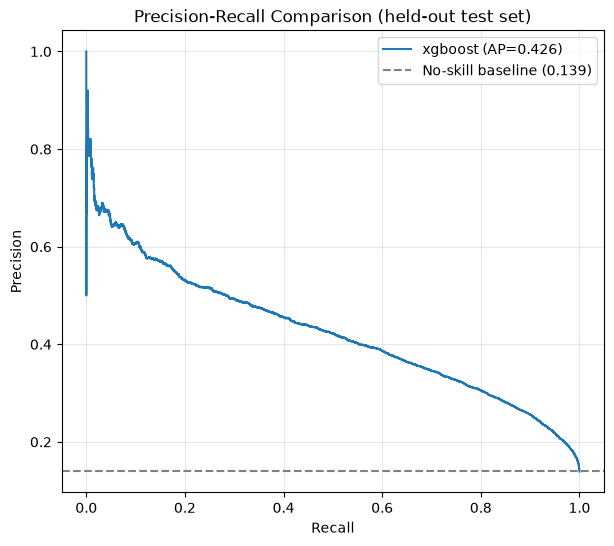

In [10]:
plt.figure(figsize=(7, 6))
for model_name, pipeline in fitted_pipelines.items():
    y_prob = pipeline.predict_proba(x_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{model_name} (AP={ap:.3f})")

baseline = y_test.mean()
plt.axhline(baseline, linestyle="--", color="gray", label=f"No-skill baseline ({baseline:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Comparison (held-out test set)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

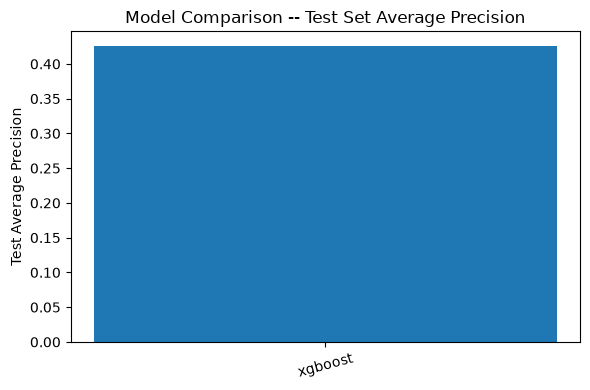

In [11]:
plt.figure(figsize=(6, 4))
plt.bar(comparison_df["model"], comparison_df["test_average_precision"])
plt.ylabel("Test Average Precision")
plt.title("Model Comparison -- Test Set Average Precision")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Pick the winner and choose a deployment threshold

In [12]:
best_model_name = comparison_df.iloc[0]["model"]
print(f"Best model: {best_model_name}")


def select_threshold(y_true, y_prob, target_recall=None):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    precision, recall = precision[:-1], recall[:-1]

    if target_recall is not None:
        eligible = recall >= target_recall
        if not eligible.any():
            raise ValueError(f"No threshold on this data achieves recall >= {target_recall}")
        best_idx = np.argmax(np.where(eligible, precision, -1))
    else:
        f1 = 2 * precision * recall / (precision + recall + 1e-12)
        best_idx = np.argmax(f1)

    return thresholds[best_idx], precision[best_idx], recall[best_idx]


best_pipeline_on_test = fitted_pipelines[best_model_name]
y_prob_test = best_pipeline_on_test.predict_proba(x_test)[:, 1]
chosen_threshold, thr_precision, thr_recall = select_threshold(y_test, y_prob_test, TARGET_RECALL)

print(
    f"""Selected decision threshold: {chosen_threshold:.4f}
    -> precision={thr_precision:.3f}, recall={thr_recall:.3f}"""
)

Best model: xgboost
Selected decision threshold: 0.6134
    -> precision=0.390, recall=0.595


## Sanity-check what the winning model is actually keying on

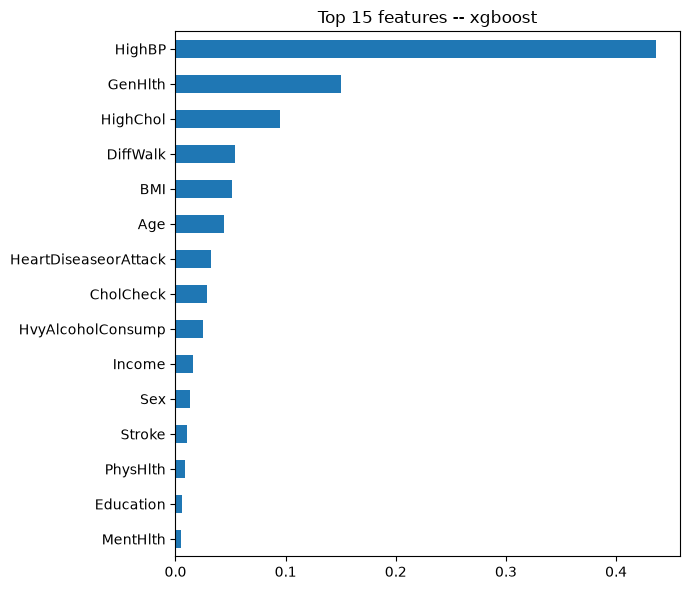

In [13]:
def get_feature_importance(pipeline: Pipeline, model_name: str) -> pd.Series:
    if model_name == "logistic_regression":
        model = pipeline.named_steps["lr"]
        feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
        return pd.Series(model.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)

    step_name = "rf" if model_name == "random_forest" else "xgb"
    model = pipeline.named_steps[step_name]
    return pd.Series(model.feature_importances_, index=x.columns).sort_values(ascending=False)


importance = get_feature_importance(fitted_pipelines[best_model_name], best_model_name)

plt.figure(figsize=(7, 6))
importance.head(15).iloc[::-1].plot(kind="barh")
plt.title(f"Top 15 features -- {best_model_name}")
plt.tight_layout()
plt.show()

## Refit the winner on the full dataset and persist for deployment

In [18]:
final_params = tuning_results[best_model_name]["best_params"]
final_pipeline = MODEL_BUILDERS[best_model_name](final_params)
final_pipeline.fit(x, y)
print(f"Refit {best_model_name} on the full dataset ({len(df):,} rows).")

Refit xgboost on the full dataset (253,680 rows).


In [19]:
joblib.dump(final_pipeline, MODEL_OUTPUT_PATH)

deployment_metadata = {
    "model_name": best_model_name,
    "trained_on": datetime.now().isoformat(),
    "trained_on_n_rows": len(df),
    "hyperparameters": final_params,
    "decision_threshold": float(chosen_threshold),
    "tuning_cv_score": tuning_results[best_model_name]["best_score"],
    "test_set_average_precision": float(
        comparison_df.loc[comparison_df["model"] == best_model_name, "test_average_precision"].item()
    ),
    "test_set_roc_auc": float(
        comparison_df.loc[comparison_df["model"] == best_model_name, "test_roc_auc"].item()
    ),
    "features": list(x.columns),
    "target": "Diabetes_binary",
    "all_models_compared": comparison_df.to_dict(orient="records"),
    "library_versions": {
        "xgboost": __import__("xgboost").__version__,
        "scikit-learn": __import__("sklearn").__version__,
    },
}

with open(METADATA_OUTPUT_PATH, "w") as f:
    json.dump(deployment_metadata, f, indent=2)

print(f"Saved model to {MODEL_OUTPUT_PATH}")
print(f"Saved metadata to {METADATA_OUTPUT_PATH}")

Saved model to ../model/best_model.pkl
Saved metadata to ../model/model_metadata.json
